# Normalized squared-IEM tilt ($f_{2}$) — $\lambda$ as temperature

Companion to `phase2_pcn_calibration.ipynb`. That notebook tilts with the **expected IEM distance**

$$f_{1}(x) := \mathbb{E}_{x'\sim p}[D_{IEM}(x,x')].$$

Here we present the **normalized expected squared** IEM tilt

$$f_{2}(x) := \frac{\mathbb{E}_{x'\sim p}[D^2_{IEM}(x,x')]}{\mathbb{E}_{x',x''\sim p}[D^2_{IEM}(x',x'')]},$$

and sample from $q_{\lambda}(x)\propto p(x)\exp(\lambda f_{2}(x))$ with the *same* gradient-free SMC / pCN sampler.

Two library pieces make this a drop-in:
- `SquaredGlobalIEMDistance` — returns $D^2_{IEM}$ (the pre-sqrt IEM integral), injectable into any reference selector;
- `RandomRefs(...).normalized_reward(R)` — the $f_{2}$ reduction: expected squared distance divided by the constant denominator $\mathbb{E}_{x',x''\sim p}[D^2_{IEM}]$, estimated by reusing the frozen refs.

Because $f_{2}$ is **normalized**, we can now treat $\lambda$ directly as an **inverse-temperature** and sweep it.

In [6]:
import sys, math, time
sys.path.insert(0, '.')                    # notebook lives in the repo root's notebooks/; keep parity with phase2
import torch
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture
from creativity_measure import (
    Density, SquaredGlobalIEMDistance,
    grid_normalize, make_grid, density_generator, PCNKernel, adaptive_tempering_smc_sample,
)
from creativity_measure.refset import RandomRefs

dtype = torch.float64
torch.set_default_dtype(dtype)

# --- Swiss Roll with a hole: the SAME 2D dataset as phase2 (reused verbatim) ---
DDIM = 2
_X, _t = make_swiss_roll(n_samples=5000, noise=0.0, random_state=42)
_X2d = _X[:, [0, 2]]
_keep = ~((_t >= 8.5) & (_t <= 9.5))                          # remove a wrap -> the "hole"
_gmm = GaussianMixture(n_components=24, covariance_type='spherical', random_state=42).fit(_X2d[_keep])
MEANS = torch.tensor(_gmm.means_, dtype=dtype)
VARS = torch.tensor(_gmm.covariances_, dtype=dtype)
LOGW = torch.log(torch.tensor(_gmm.weights_, dtype=dtype))

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS; quad = diff.pow(2).sum(-1) / VARS
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * VARS) + LOGW, dim=-1)

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device); var = gamma ** 2 * VARS + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS; quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * var) + LOGW, dim=-1)

def roll_sample(n, generator=None):
    idx = torch.multinomial(torch.exp(LOGW), n, replacement=True, generator=generator)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype, generator=generator)

p = Density(log_pX, log_pY, sample_fn=roll_sample, d=2)

# --- CHANGED vs phase2: squared IEM distance + normalized reward; NO lambda_0 ---
S = torch.sqrt(VARS).mean().item(); C = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2; GAMMA_HI = 2.0 ** 10
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), 24, base=2, dtype=dtype)
D2 = SquaredGlobalIEMDistance(p, GAMMAS, num_eps=4, seed=123)          # D_IEM^2   (was GlobalIEMDistance)
reward = RandomRefs(p, distance=D2, seed=0).normalized_reward(16)      # f2 = E[D^2] / E_pair[D^2]  (was .reward)
REFS = reward.x_refs
G = density_generator(p, sigma_min=2e-3, sigma_max=150.0, n_steps=48)  # reused verbatim (depends only on p)

# grid + the lambda-INDEPENDENT tilt field f2 (compute once, reuse for every lambda)
GP, XX, YY, CELL = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
LOG_P = p.log_p_X(GP)
F2_GRID = reward(GP)

def hist_pmf(s, gn=50, lo=-15.0, hi=15.0):
    ci = (((s[:, 0] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    ri = (((s[:, 1] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    k = ri * gn + ci; c = torch.zeros(gn * gn, dtype=dtype); c.scatter_add_(0, k, torch.ones(s.shape[0], dtype=dtype))
    return c / c.sum()

# boundary mask: mass here == the tilt has overpowered p's tail (the normalizability ceiling)
GN = 50
_b = torch.zeros(GN, GN, dtype=torch.bool); _b[0, :] = _b[-1, :] = _b[:, 0] = _b[:, -1] = True
BOUNDARY = _b.reshape(-1)

# generator fidelity (same check as phase2): pCN needs G(N(0, I)) ~ p
_z = torch.randn(3000, 2, generator=torch.Generator().manual_seed(0), dtype=dtype)
TV_G = 0.5 * float((hist_pmf(G(_z)) - hist_pmf(p.sample(3000))).abs().sum())
print(f"K={MEANS.shape[0]} comps  S={S:.2f}  denom C = E_pair[D^2] = {reward._denom:.3f}")
print(f"f2 on grid: median={F2_GRID.median():.2f}  max={F2_GRID.max():.1f}   log p: [{LOG_P.min():.0f}, {LOG_P.max():.0f}]")
print(f"generator fidelity TV(G(z), p.sample) = {TV_G:.3f}   (reused from phase2)")

K=24 comps  S=0.68  denom C = E_pair[D^2] = 1.343
f2 on grid: median=6.10  max=180.4   log p: [-250, -3]
generator fidelity TV(G(z), p.sample) = 0.255   (reused from phase2)


## Does more sampler effort rescue the hard target? ($\lambda = 1.25$)

Here we **hold $\lambda = 1.25$ fixed** and pump the two convergence knobs in a 3×3:

- **rows** — `ess_target` $\in \{0.90, 0.95, 0.98\}$ (finer tempering schedule; high values only),
- **cols** — `n_mcmc` $\in \{6, 12, 18\}$ (more pCN rejuvenation moves per level).

The grid-$q$ contours are identical in every panel (same $\lambda$); only the white SMC cloud moves. If sampler effort were the bottleneck, the cloud would climb toward the high-$f_{2}$ contours as we go down / right. (Heavy cell — 9 SMC runs)

lambda=1.25: grid E_q[f2]=66.11


  ess_target=0.90  n_mcmc= 6 -> E[f2]= 2.67 (  4% of grid)  levels= 5  uniq=245/300    15s


  ess_target=0.90  n_mcmc=12 -> E[f2]= 3.16 (  5% of grid)  levels= 6  uniq=242/300    33s


  ess_target=0.90  n_mcmc=18 -> E[f2]= 3.96 (  6% of grid)  levels= 6  uniq=196/300    49s


  ess_target=0.95  n_mcmc= 6 -> E[f2]= 2.63 (  4% of grid)  levels= 6  uniq=248/300    19s


  ess_target=0.95  n_mcmc=12 -> E[f2]= 5.18 (  8% of grid)  levels=10  uniq=154/300    57s


  ess_target=0.95  n_mcmc=18 -> E[f2]= 4.13 (  6% of grid)  levels= 9  uniq=208/300    75s


  ess_target=0.98  n_mcmc= 6 -> E[f2]= 2.68 (  4% of grid)  levels=10  uniq=259/300    26s


  ess_target=0.98  n_mcmc=12 -> E[f2]= 3.75 (  6% of grid)  levels=13  uniq=224/300    67s


  ess_target=0.98  n_mcmc=18 -> E[f2]= 3.02 (  5% of grid)  levels=11  uniq=260/300    86s


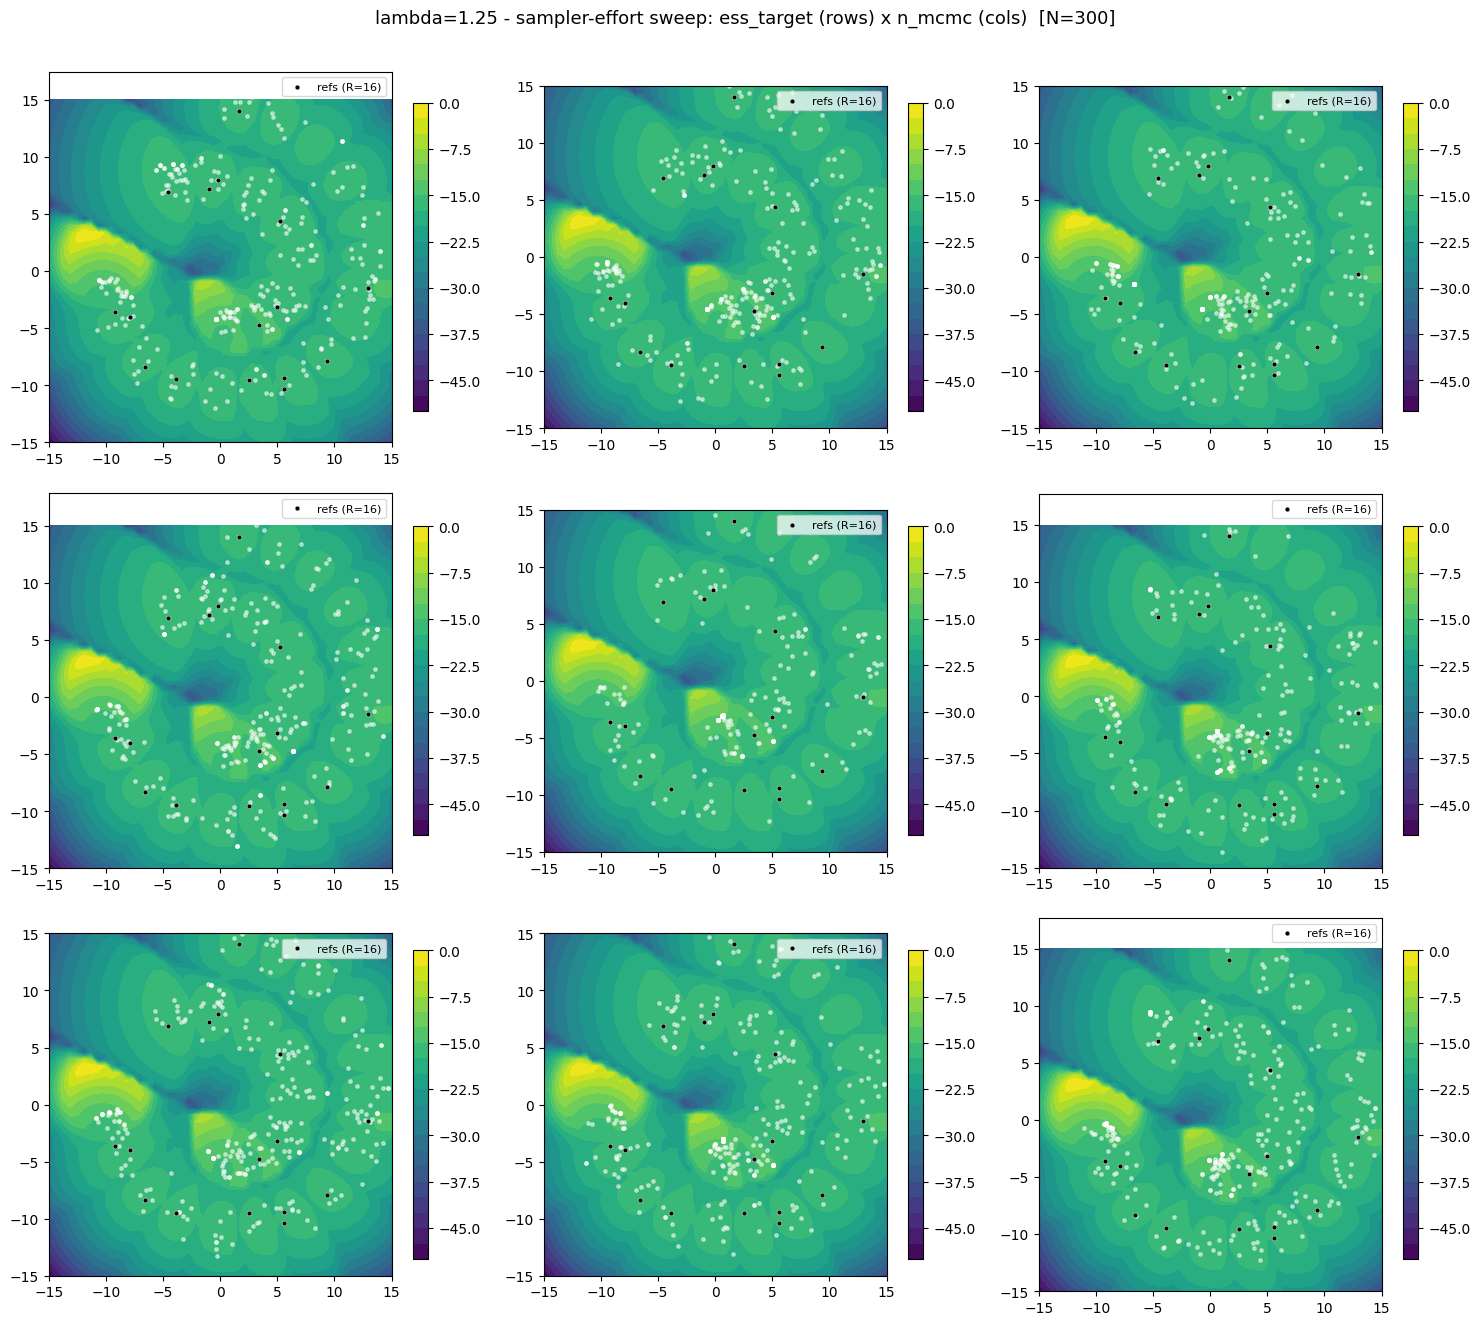

In [ ]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field, plot_samples

# Fixed lambda = 1.25. 3x3 = ess_target (rows) x n_mcmc (cols).
# Grid-q is identical in every panel; only the white SMC cloud changes.
LAM_HARD = 1.25
N_HARD = 300
ESS_TARGETS = [0.90, 0.95, 0.98]     # rows (high values only)
N_MCMCS = [6, 12, 18]                # cols

log_q_hard, q_hard, _ = grid_normalize(LOG_P + LAM_HARD * F2_GRID, CELL)
EF_GRID_HARD = float((q_hard.reshape(-1) / q_hard.reshape(-1).sum() * F2_GRID).sum())
print(f"lambda={LAM_HARD}: grid E_q[f2]={EF_GRID_HARD:.2f}")

fig, axes = plt.subplots(len(ESS_TARGETS), len(N_MCMCS),
                         figsize=(5.0 * len(N_MCMCS), 4.4 * len(ESS_TARGETS)))
for i, ess in enumerate(ESS_TARGETS):
    for j, nm in enumerate(N_MCMCS):
        ax = axes[i, j]; t = time.time()
        res = adaptive_tempering_smc_sample(reward, lam=LAM_HARD, n_particles=N_HARD,
                         kernel=PCNKernel(G, DDIM), n_mcmc=nm, ess_target=ess,
                         final_resample=True, seed=0)
        ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
        pct = ef / EF_GRID_HARD
        print(f"  ess_target={ess:.2f}  n_mcmc={nm:2d} -> E[f2]={ef:5.2f} ({pct:4.0%} of grid)  "
              f"levels={len(res.betas):2d}  uniq={uniq}/{N_HARD}  {time.time() - t:4.0f}s")
        plot_field(log_q_hard, XX, YY, ax=ax,
                   title=f"ess={ess}, n_mcmc={nm}  ({pct:.0%} of grid)", refs=REFS)
        plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"lambda={LAM_HARD} - sampler-effort sweep: ess_target (rows) x n_mcmc (cols)  [N={N_HARD}]",
    fontsize=13, y=1.005,
)
plt.tight_layout()
plt.show()

### What the ess_target + n_mcmc sweep shows

Coverage stays pinned at **4–8% of grid** across the whole 3×3 — **more effort does not rescue $\lambda = 1.25$**:

- **`n_mcmc` helps a little.** More rejuvenation moves let particles drift up the $f_{2}$ gradient (at `ess_target=0.90`, `E[f2]` climbs $2.67 \to 3.16 \to 3.96$ as `n_mcmc` $6 \to 12 \to 18$), so a few more samples reach the high-mass region — but the cloud stalls near $p$ and never crosses to the off-manifold mode. **Should try again for stronger tilts (appears later in the notebook)**.
- **`ess_target` does not** (and higher values look *more* like $p$). A finer schedule adds tempering levels ($5 \to 13$), but with a proposal anchored to $p$ each extra level mostly re-equilibrates particles back toward $p$'s bulk between the tiny $\beta$-steps. Going the *other* way — very small `ess_target` — only fakes coverage through weight degeneracy (few unique particles: e.g. the 8% cell had `uniq`=154/300 vs 242 at `ess=0.90`), **so keep it in the reliable $0.7$–$0.9$ range**.

## Into the collapse regime (grid only) — a stronger-$\lambda$ sweep

Nine increasing temperatures $\lambda \in \{1.25, 1.5, \dots, 3.25\}$ (step $0.25$), using `ess_target=0.90` and `n_mcmc=18`.
From the earlier scan, $\lambda \gtrsim 1.75$ is the **grid** collapse regime: the *finite-grid* $q$ becomes non-normalizable and its mass piles on the domain boundary.
The sweep is built to show the contrast — the grid-$q$ contours degenerate toward the corners, while the SMC cloud **should not escape the manifold** and instead converges toward the high-$f_{2}$ manifold regions.

lambda=1.25  grid E_q[f2]=  66.11  boundary= 0.0%  |  SMC E[f2]= 3.96 (  6% of grid)  levels= 6  uniq=196/300    53s


lambda=1.50  grid E_q[f2]=  71.16  boundary= 0.0%  |  SMC E[f2]= 5.56 (  8% of grid)  levels= 8  uniq=130/300    75s


lambda=1.75  grid E_q[f2]= 179.83  boundary=100.0%  |  SMC E[f2]= 6.61 (  4% of grid)  levels= 9  uniq=74/300    83s


lambda=2.00  grid E_q[f2]= 180.33  boundary=100.0%  |  SMC E[f2]= 7.13 (  4% of grid)  levels=10  uniq=46/300    94s


lambda=2.25  grid E_q[f2]= 180.38  boundary=100.0%  |  SMC E[f2]= 7.60 (  4% of grid)  levels=11  uniq=48/300   104s


lambda=2.50  grid E_q[f2]= 180.38  boundary=100.0%  |  SMC E[f2]= 9.60 (  5% of grid)  levels=14  uniq=112/300   131s


lambda=2.75  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=21.18 ( 12% of grid)  levels=19  uniq=176/300   177s


lambda=3.00  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=26.77 ( 15% of grid)  levels=22  uniq=155/300   206s


lambda=3.25  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=28.44 ( 16% of grid)  levels=23  uniq=134/300   218s


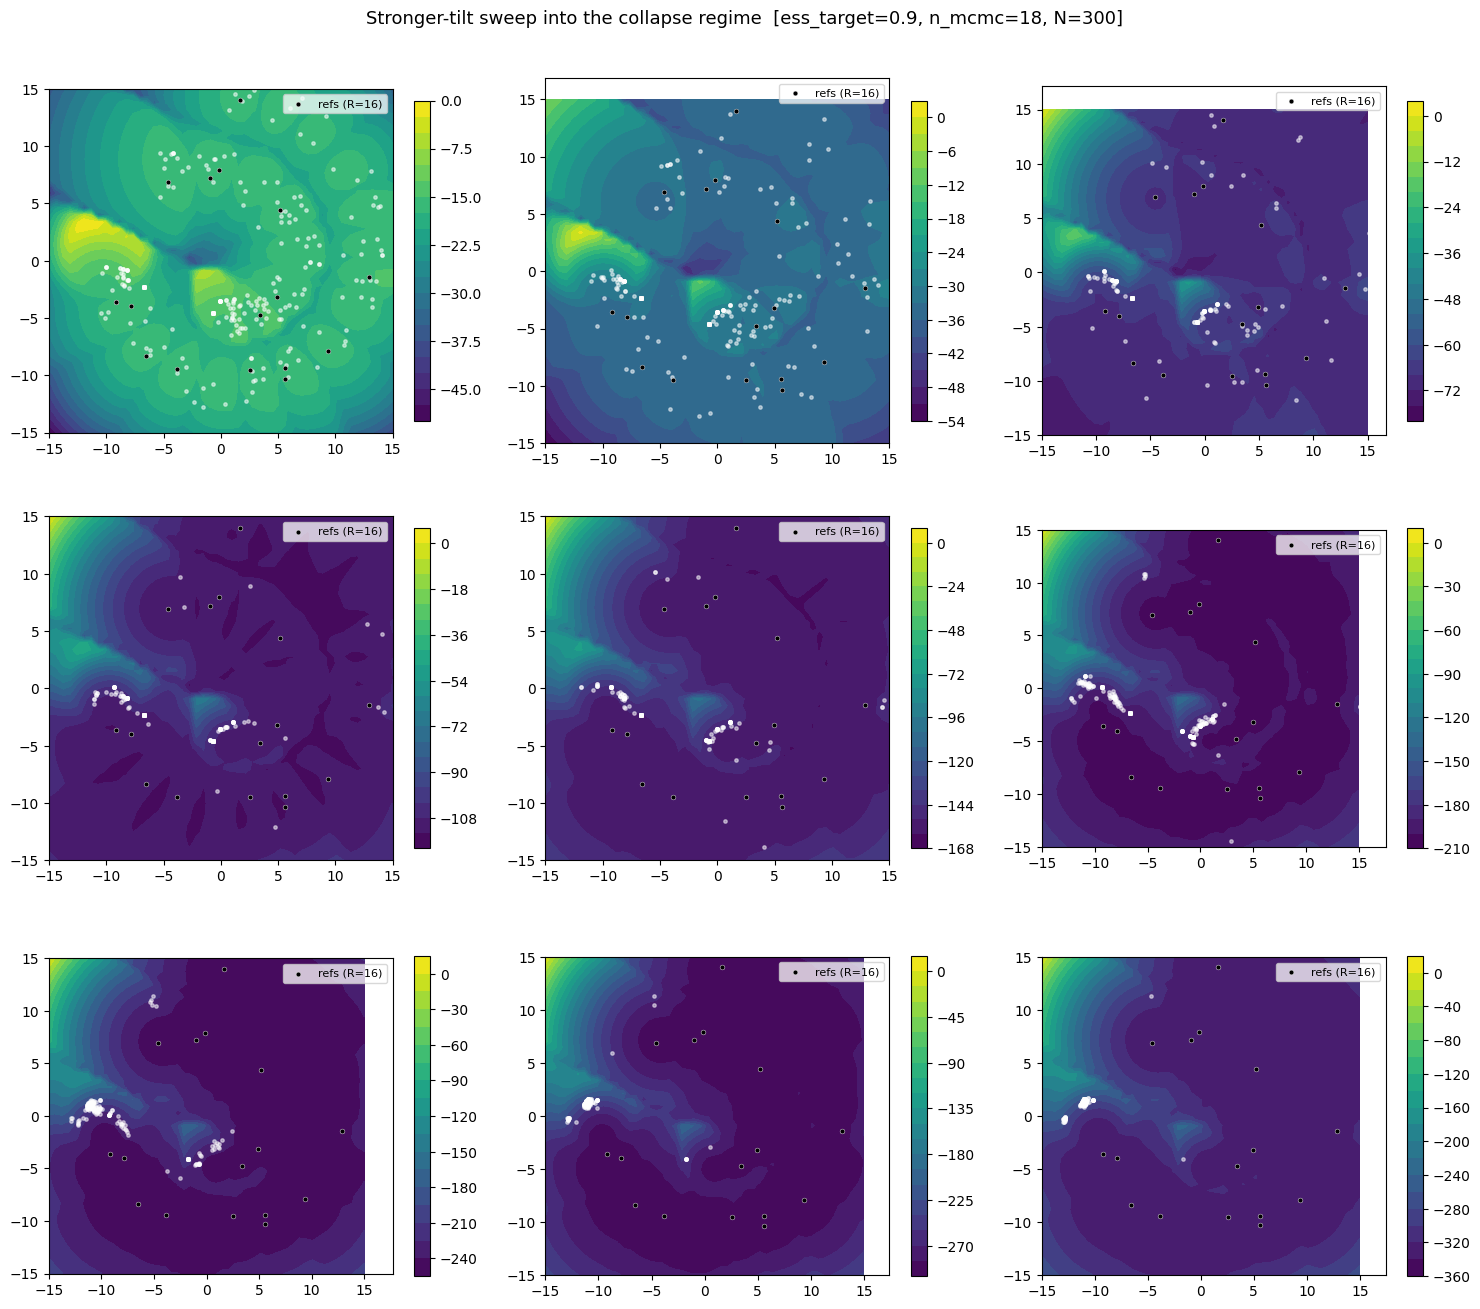

In [ ]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field, plot_samples

ESS_BEST, NMCMC_BEST = 0.90, 18
N_STRONG = 300
STRONG_LAMBDAS = [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25]   # 9 values -> 3x3, increasing

fig, axes = plt.subplots(3, 3, figsize=(15.0, 13.2))
for ax, lam in zip(axes.ravel(), STRONG_LAMBDAS):
    t = time.time()
    log_q, q, _ = grid_normalize(LOG_P + lam * F2_GRID, CELL)
    qpmf = q.reshape(-1) / q.reshape(-1).sum()
    ef_grid = float((qpmf * F2_GRID).sum()); bmass = float(qpmf[BOUNDARY].sum())
    res = adaptive_tempering_smc_sample(reward, lam=lam, n_particles=N_STRONG,
                     kernel=PCNKernel(G, DDIM), n_mcmc=NMCMC_BEST, ess_target=ESS_BEST,
                     final_resample=True, seed=0)
    ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
    print(f"lambda={lam:4.2f}  grid E_q[f2]={ef_grid:7.2f}  boundary={bmass:5.1%}  |  "
          f"SMC E[f2]={ef:5.2f} ({ef / ef_grid:4.0%} of grid)  levels={len(res.betas):2d}  "
          f"uniq={uniq}/{N_STRONG}  {time.time() - t:4.0f}s")
    tag = "  [collapse]" if bmass > 0.20 else ""
    plot_field(log_q, XX, YY, ax=ax,
               title=f"lambda = {lam}   (SMC {ef / ef_grid:.0%} of grid){tag}", refs=REFS)
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"Stronger-tilt sweep into the collapse regime  "
    f"[ess_target={ESS_BEST}, n_mcmc={NMCMC_BEST}, N={N_STRONG}]",
    fontsize=13, y=1.002,
)
plt.tight_layout()
plt.show()

### What the stronger-$\lambda$ sweep shows — SMC does not escape

The grid and SMC panels tell **different stories**:

- **Mass doesn't escape in SMC.** Every particle is $x = G(z)$: the pCN kernel proposes a *latent* $z'$ and maps it through the generator $G$, and resampling only reselects existing particle locations. So the particle support is always $\subseteq \mathrm{Image}(G) \approx \mathrm{supp}\,p$ (the data manifold). No step can place a particle in the far off-manifold void where the grid-version dumps its probability mass — **the tilt only reweights based on the manifold**.
- **SMC converges to the right places, just slower than the grid-version.** Instead of escaping, the white cloud concentrates on the highest-$f_{2}$ *reachable* points — the manifold edges / hole boundary that the valid $\lambda\approx 1.25$ tilt already highlighted — drifting further out as $\lambda$ grows ($\mathbb{E}[f_{2}]$ crept $4 \to 28$ over $\lambda = 1.25 \to 3.25$). The grid reweights globally and instantly; **SMC must *transport* particles along the manifold with local pCN moves, so it lags.**
- **Hence `% of grid` is the wrong yardstick past $\lambda\approx 1.5$** (`boundary_mass` $\to 100\%$): its denominator is the boundary artifact, not a real target. For strong $\lambda$ read the $\mathbb{E}[f_{2}]$ trend, `uniq` / `ess_history`, and the visual convergence to high-novelty manifold regions instead.

**This is the *desirable* behavior for the creativity goal: SMC returns creative-but-valid manifold-based samples. The grid-version is the misleading version here, not the SMC version.**

## Takeaways

- **$f_{2}$ is a drop-in.** `SquaredGlobalIEMDistance` + `.normalized_reward(R)`, sampled by the same SMC / pCN stack — every other object from phase2 (SMC + pCN kernel + $f_1$ non-normilized distance) is reused as-is.
- **The grid target has a normalizability ceiling; SMC does not.** The *literal* $q_{\lambda}\propto p\exp(\lambda f_{2})$ over $\mathbb{R}^2$ (and its grid enumeration) diverges once the squared reward out-grows $\log p$'s decay (here $\lambda\gtrsim 1.5$: `boundary_mass` $\to$ 1). SMC never sees this — its particles are $x = G(z)$, confined to the generator manifold where $f_{2}$ is bounded, so its tilted target stays a **proper distribution for every $\lambda$**.
- **SMC can't escape — it reweights within the manifold.** As $\lambda$ grows the cloud converges to high-novelty on-manifold regions (manifold edges / the hole), *slower* than the grid because pCN transports particles locally rather than reweighting globally. This is the desirable behavior for the creativity goal.
- Should use the $\mathbb{E}[f_{2}]$ trend / `uniq` / visual convergence to guide hyperparams choise.

*Note:* Altough the constant denominator $\mathbb{E}_{x',x''\sim p}[D^2_{IEM}]$ makes $f_{2}$ unitless, should consider re-introducing a method for finding an initial $\lambda$ values, such as $\lambda \in [1,2,3] \cdot \frac{1}{\mathrm{std_p}(f)}$.

## Choosing $\lambda$ without the grid — an SMC-only recipe for high dimensions

This section selects $\lambda$ from SMC-computable and base-sample quantities only (shoudn't grid-version related methods). The $\lambda=1.25$ grid field appears **purely as a visual fixed background - it does not represent the ground truth!**

**The inverse-temperature scale.** phase2 used $\lambda_{0}=\operatorname{std}\!\big(\log p_{X}(\text{refs})\big)/\operatorname{std}\!\big(f(\text{refs})\big)$, whose numerator needs the base log-density $\log p_{X}$ — which is hard to compute in high-d. The transferable half is
$$\lambda_{s}=\frac{1}{\operatorname{std}_{p}(f_{2})},$$
computed from $x\sim p$ (via $G$) alone. Because the reward is frozen-deterministic (fixed Brownian seed + frozen refs), $f_{2}$ is a deterministic function of $x$, so the plug-in $\operatorname{std}_{p}(f_{2})$ over base samples already gives the scale — no separate estimator-variance term is needed. (In 2D we still have $\log p$, so we print the full $\lambda_{0}$ too, only to check $\lambda_{s}$ lands in the same ballpark.)

The three cells below (1) run the sweep over the fixed escaping-grid background, (2) plot every SMC-only $\lambda$-signal to visually choose a selection rule, and (3) expose the SMC process history and the adaptive-rejuvenation stopping rules.

std_p(f2)=0.546  ->  lambda_s = 1/std_p(f2) = 1.83   (phase2 lambda_0 = std(log p)/std(f) = 1.75, 2D-only)

lambda=0.50  E_smc[f2]=  1.36  uniq/N= 89%  min-ESS/N= 87%  levels= 1  sweeps= 13  acc=0.85  |  ESS/N_1shot= 85%    84s
lambda=0.75  E_smc[f2]=  1.62  uniq/N= 91%  min-ESS/N= 85%  levels= 2  sweeps= 17  acc=0.79  |  ESS/N_1shot= 57%   115s
lambda=1.00  E_smc[f2]=  2.12  uniq/N= 88%  min-ESS/N= 85%  levels= 3  sweeps= 33  acc=0.70  |  ESS/N_1shot= 25%   199s
lambda=1.25  E_smc[f2]=  3.11  uniq/N= 80%  min-ESS/N= 85%  levels= 5  sweeps= 55  acc=0.55  |  ESS/N_1shot=  8%   325s
lambda=1.50  E_smc[f2]=  4.52  uniq/N= 57%  min-ESS/N= 85%  levels= 6  sweeps= 61  acc=0.48  |  ESS/N_1shot=  3%   353s
lambda=1.75  E_smc[f2]=  5.90  uniq/N= 36%  min-ESS/N= 85%  levels= 7  sweeps= 66  acc=0.41  |  ESS/N_1shot=  1%   379s
lambda=2.00  E_smc[f2]=  6.93  uniq/N= 26%  min-ESS/N= 85%  levels= 9  sweeps= 78  acc=0.32  |  ESS/N_1shot=  0%   445s
lambda=2.50  E_smc[f2]=  8.15  uniq/N= 13%  min-ESS/

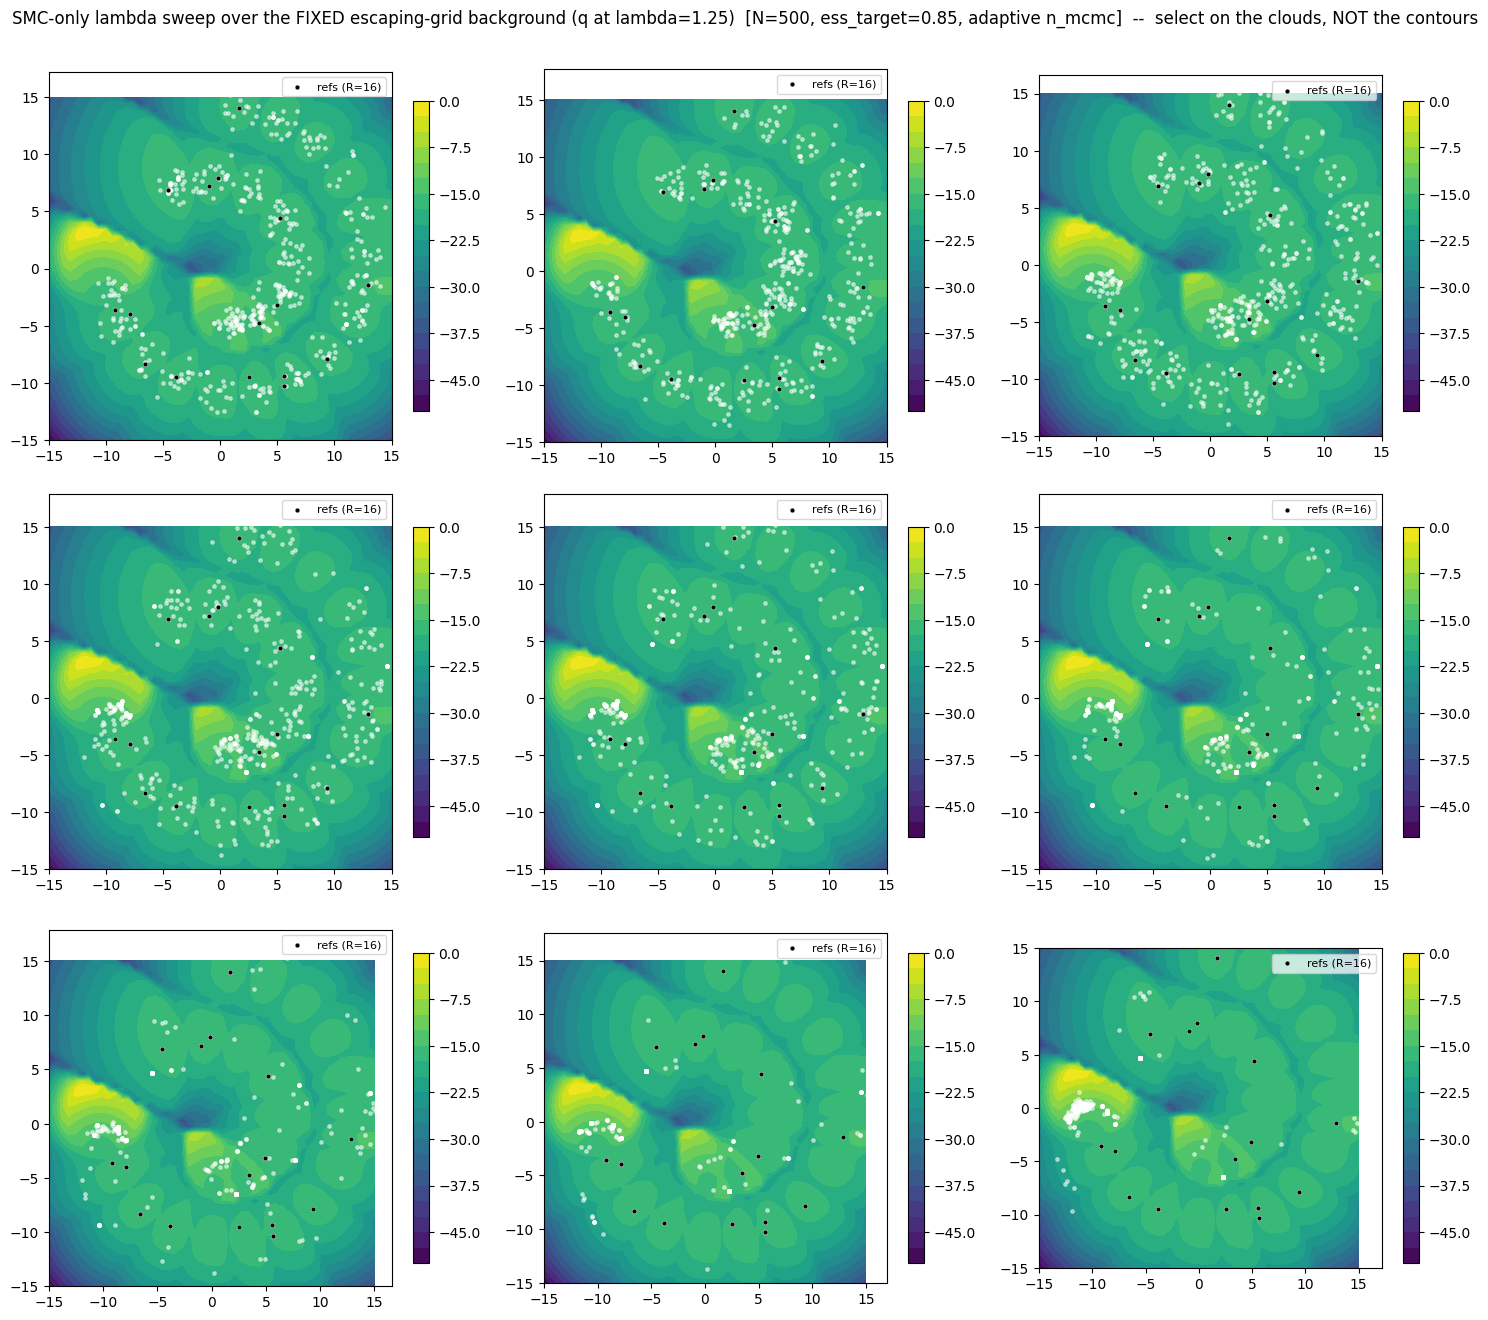

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from creativity_measure import plot_field, plot_samples

LAMBDAS_SEL = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]  # 3x3: flat -> interesting -> collapse
N_SEL       = 500
ESS_TARGET  = 0.85            # inside the reliable 0.7-0.9 band
SEED        = 0
M_BASE      = 2000            # base samples for std_p(f2) and the one-shot ESS/N screen

# --- temperature scale (SMC-only analog of phase2's lambda_0) ------------------------------------
_gen    = torch.Generator().manual_seed(SEED)
X_BASE  = p.sample(M_BASE, generator=_gen)          # x ~ p
F2_BASE = reward(X_BASE)                            # f2 on base samples (frozen -> deterministic)
STD_F2  = float(F2_BASE.std())
LAMBDA_S = 1.0 / STD_F2                             # transferable scale = 1/std_p(f2); NO log p needed
LAMBDA_0_2D = float(p.log_p_X(REFS).std() / reward(REFS).std())   # phase2 lambda_0 -- 2D-ONLY (uses log p)
print(f"std_p(f2)={STD_F2:.3f}  ->  lambda_s = 1/std_p(f2) = {LAMBDA_S:.2f}   "
      f"(phase2 lambda_0 = std(log p)/std(f) = {LAMBDA_0_2D:.2f}, 2D-only)\n")

# --- fixed grid background: q_lambda at lambda=1.25, computed ONCE ----------------------
LAM_BG = 1.25
log_q_bg, _, _ = grid_normalize(LOG_P + LAM_BG * F2_GRID, CELL)

# --- the sweep ----------------------------------------------------------------------------------
results: dict[float, object] = {}   # lam -> full AdaptiveTemperingSMCResult (for the history / stopping-rule cell)
rows: list[dict[str, float]] = []   # lam -> collected SMC-only signals
fig, axes = plt.subplots(3, 3, figsize=(15.0, 13.2))
for ax, lam in zip(axes.ravel(), LAMBDAS_SEL):
    t = time.time()
    res = adaptive_tempering_smc_sample(reward, lam=lam, n_particles=N_SEL,
                     kernel=PCNKernel(G, DDIM), n_mcmc=None,   # ADAPTIVE -> surfaces the stopping rules
                     ess_target=ESS_TARGET, final_resample=True, seed=SEED)
    results[lam] = res
    fX        = reward(res.X)
    ef_smc    = float(fX.mean())
    uniq      = int(res.X.unique(dim=0).shape[0])
    levels    = len(res.betas)
    min_ess_n = min(res.ess_history) / N_SEL
    acc_mean  = float(np.mean(res.acc_history))
    sweeps    = int(sum(res.n_mcmc_history))
    # pre-SMC importance-sampling diagnostics from base samples only:
    w_os     = torch.softmax(lam * F2_BASE, 0)
    ess_os   = float(1.0 / (M_BASE * (w_os ** 2).sum()))       # one-shot tilt ESS/N in [1/M, 1]
    logw_var = (lam ** 2) * float(F2_BASE.var())               # Var_p(lambda f2): IS-degeneracy predictor
    rows.append(dict(lam=lam, ef_smc=ef_smc, uniq_frac=uniq / N_SEL, levels=levels,
                     min_ess_n=min_ess_n, acc=acc_mean, sweeps=sweeps,
                     ess_os=ess_os, logw_var=logw_var))
    print(f"lambda={lam:4.2f}  E_smc[f2]={ef_smc:6.2f}  uniq/N={uniq/N_SEL:4.0%}  "
          f"min-ESS/N={min_ess_n:4.0%}  levels={levels:2d}  sweeps={sweeps:3d}  acc={acc_mean:4.2f}  |  "
          f"ESS/N_1shot={ess_os:4.0%}  {time.time()-t:4.0f}s")
    plot_field(log_q_bg, XX, YY, ax=ax, title=f"lambda = {lam}   (uniq/N={uniq/N_SEL:.0%})", refs=REFS)
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"SMC-only lambda sweep over the FIXED escaping-grid background (q at lambda={LAM_BG})  "
    f"[N={N_SEL}, ess_target={ESS_TARGET}, adaptive n_mcmc]  --  select on the clouds, NOT the contours",
    fontsize=12, y=1.003,
)
plt.tight_layout()
plt.show()

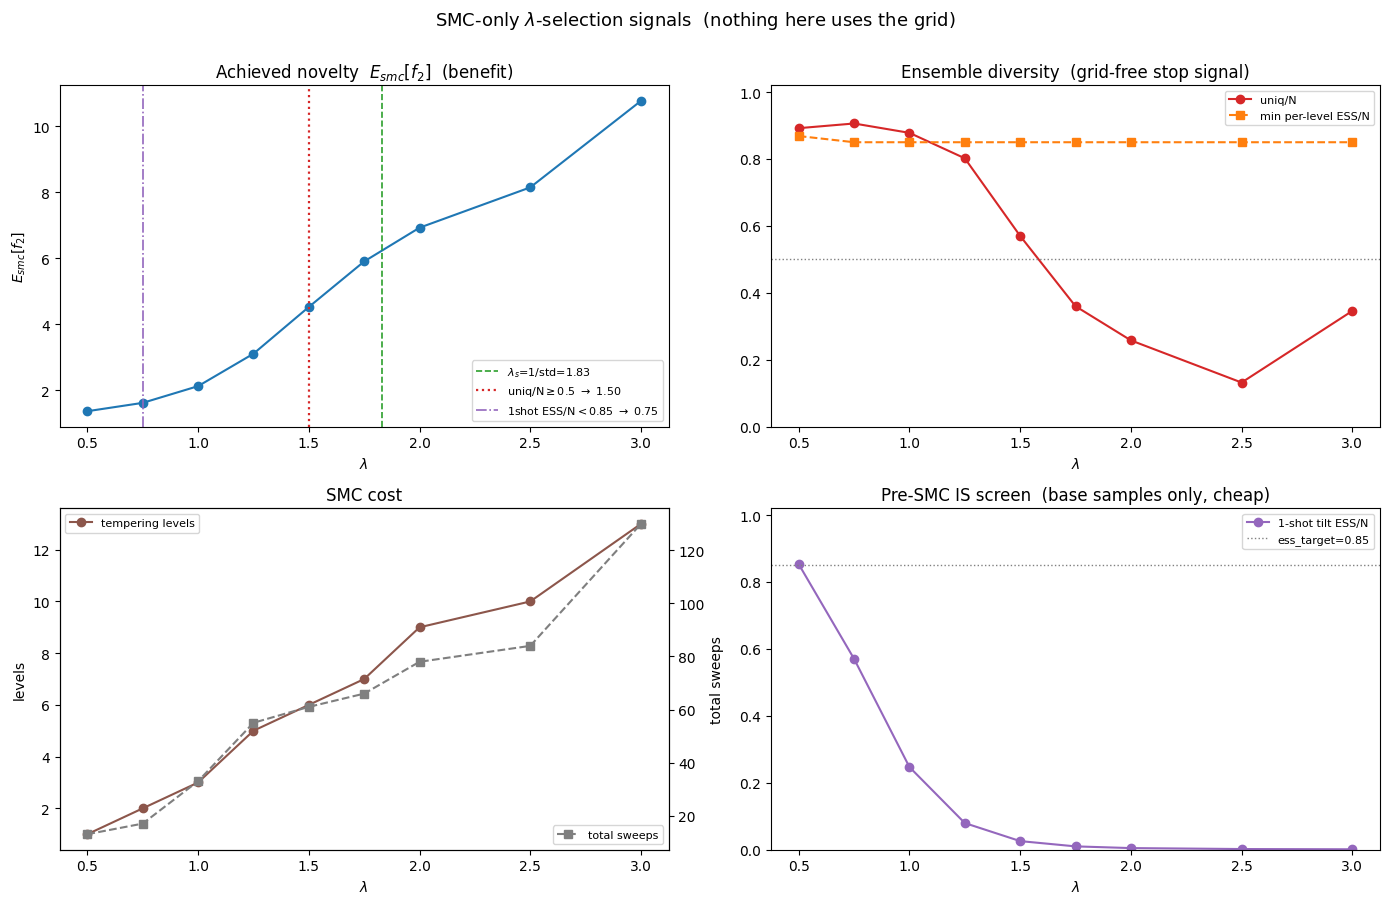

candidate lambda*:   scale lambda_s=1.83   diversity-floor(uniq/N>=0.5)=1.50   1shot-ESS cross=0.75   benefit-per-level knee=1.50


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

lams  = np.array([r["lam"]        for r in rows])
ef    = np.array([r["ef_smc"]     for r in rows])
uniq  = np.array([r["uniq_frac"]  for r in rows])
mess  = np.array([r["min_ess_n"]  for r in rows])
lev   = np.array([r["levels"]     for r in rows])
swp   = np.array([r["sweeps"]     for r in rows])
essos = np.array([r["ess_os"]     for r in rows])

# --- candidate lambda* per rule (all SMC-only) ---------------------------------------------------
DIV_FLOOR = 0.5
cand_div  = float(lams[uniq >= DIV_FLOOR].max()) if (uniq >= DIV_FLOOR).any() else float("nan")  # largest lam keeping diversity
_below    = lams[essos < ESS_TARGET]
cand_ess  = float(_below.min()) if _below.size else float("nan")                                 # first lam whose 1-shot ESS/N < ess_target
_dlev     = np.diff(lev); _gain = np.diff(ef)
_ratio    = np.where(_dlev > 0, _gain / np.maximum(_dlev, 1), _gain)                              # E[f2] gain per added level
cand_knee = float(lams[1:][int(np.argmax(_ratio))]) if _ratio.size else float("nan")

def _mark(a):
    a.axvline(LAMBDA_S, color="tab:green",  ls="--", lw=1.2, label=f"$\\lambda_s$=1/std={LAMBDA_S:.2f}")
    if not np.isnan(cand_div):
        a.axvline(cand_div, color="tab:red",   ls=":",  lw=1.6, label=f"uniq/N$\\geq${DIV_FLOOR:.1f} $\\to$ {cand_div:.2f}")
    if not np.isnan(cand_ess):
        a.axvline(cand_ess, color="tab:purple", ls="-.", lw=1.2, label=f"1shot ESS/N$<${ESS_TARGET} $\\to$ {cand_ess:.2f}")

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
# (1) benefit -- rises monotonically, so NOT a stopping signal on its own
a = ax[0, 0]; a.plot(lams, ef, "o-", color="tab:blue")
a.set_title("Achieved novelty  $E_{smc}[f_2]$  (benefit)"); a.set_xlabel("$\\lambda$"); a.set_ylabel("$E_{smc}[f_2]$")
_mark(a); a.legend(fontsize=8)
# (2) diversity -- the grid-free STOP signal
a = ax[0, 1]; a.plot(lams, uniq, "o-", color="tab:red",    label="uniq/N")
a.plot(lams, mess, "s--", color="tab:orange", label="min per-level ESS/N")
a.axhline(DIV_FLOOR, color="gray", ls=":", lw=1); a.set_ylim(0, 1.02)
a.set_title("Ensemble diversity  (grid-free stop signal)"); a.set_xlabel("$\\lambda$"); a.legend(fontsize=8)
# (3) cost
a = ax[1, 0]; a.plot(lams, lev, "o-", color="tab:brown", label="tempering levels")
a2 = a.twinx(); a2.plot(lams, swp, "s--", color="tab:gray", label="total sweeps")
a.set_title("SMC cost"); a.set_xlabel("$\\lambda$"); a.set_ylabel("levels"); a2.set_ylabel("total sweeps")
a.legend(fontsize=8, loc="upper left"); a2.legend(fontsize=8, loc="lower right")
# (4) pre-SMC screen (base samples only)
a = ax[1, 1]; a.plot(lams, essos, "o-", color="tab:purple", label="1-shot tilt ESS/N")
a.axhline(ESS_TARGET, color="gray", ls=":", lw=1, label=f"ess_target={ESS_TARGET}")
a.set_ylim(0, 1.02); a.set_title("Pre-SMC IS screen  (base samples only, cheap)")
a.set_xlabel("$\\lambda$"); a.legend(fontsize=8)
fig.suptitle("SMC-only $\\lambda$-selection signals  (nothing here uses the grid)", fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

print(f"candidate lambda*:   scale lambda_s={LAMBDA_S:.2f}   diversity-floor(uniq/N>={DIV_FLOOR})={cand_div:.2f}   "
      f"1shot-ESS cross={cand_ess:.2f}   benefit-per-level knee={cand_knee:.2f}")

MIN_N_MCMC=4  MAX_N_MCMC=30   (adaptive rejuvenation bounds)

=== lambda=0.75   levels=2   total sweeps=17 ===
lvl    beta      ESS    acc  n_mcmc  stop_reason
  0   0.703    425.0   0.83      12       decorr
  1   1.000    462.9   0.76       5       decorr

=== lambda=1.25   levels=5   total sweeps=55 ===
lvl    beta      ESS    acc  n_mcmc  stop_reason
  0   0.422    425.0   0.83      12       decorr
  1   0.659    425.0   0.67      10       decorr
  2   0.837    425.0   0.52      20      plateau
  3   0.988    425.0   0.38       6      plateau
  4   1.000    499.5   0.37       7      plateau

=== lambda=2.5   levels=10   total sweeps=84 ===
lvl    beta      ESS    acc  n_mcmc  stop_reason
  0   0.211    425.0   0.83      12       decorr
  1   0.329    425.0   0.67      10       decorr
  2   0.419    425.0   0.52      20      plateau
  3   0.494    425.0   0.38       6      plateau
  4   0.562    425.0   0.24       6      plateau
  5   0.631    425.0   0.12       6      plateau
  6  

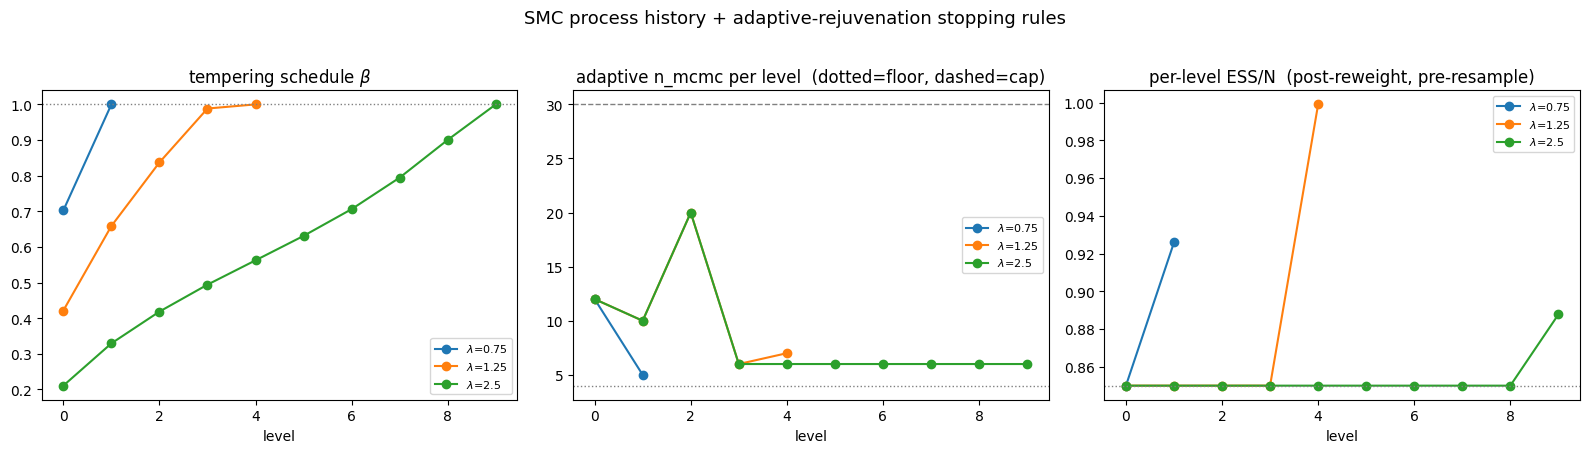

In [ ]:
import matplotlib.pyplot as plt
from creativity_measure.adaptive_tempering_smc import MIN_N_MCMC, MAX_N_MCMC

# =================================================================================================
# SMC process history + the adaptive-rejuvenation STOPPING RULES. Because the sweep ran n_mcmc=None,
# each level chose its own sweep count and reports why it stopped:
#   "decorr"  -> particles decorrelated from their resampled parents (primary, geometry-aware)
#   "plateau" -> weight-aware mean/std of f2 stopped moving (secondary early-exit) [NOTE: I LATER FOUND OUT IT CAUSES TOO-EARLY STOPPING AND REMOVED IT]
#   "cap"     -> hit MAX_N_MCMC without either firing
# Both early stops are gated by the MIN_N_MCMC floor.
# =================================================================================================
REP_LAMBDAS = [0.75, 1.25, 2.5]     # representative: gentle / edge-of-collapse / deep-collapse
print(f"MIN_N_MCMC={MIN_N_MCMC}  MAX_N_MCMC={MAX_N_MCMC}   (adaptive rejuvenation bounds)")
for lam in REP_LAMBDAS:
    res = results[lam]
    print(f"\n=== lambda={lam}   levels={len(res.betas)}   total sweeps={sum(res.n_mcmc_history)} ===")
    print(f"{'lvl':>3} {'beta':>7} {'ESS':>8} {'acc':>6} {'n_mcmc':>7} {'stop_reason':>12}")
    for i, (b, ess, ac, nm, rs) in enumerate(zip(
            res.betas, res.ess_history, res.acc_history, res.n_mcmc_history, res.stop_reason_history)):
        print(f"{i:>3} {b:7.3f} {ess:8.1f} {ac:6.2f} {nm:7d} {rs:>12}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
for lam in REP_LAMBDAS:
    res = results[lam]
    xs = list(range(len(res.betas)))
    ax[0].plot(xs, res.betas, "o-", label=f"$\\lambda$={lam}")
    ax[1].plot(xs, res.n_mcmc_history, "o-", label=f"$\\lambda$={lam}")
    ax[2].plot(xs, [e / N_SEL for e in res.ess_history], "o-", label=f"$\\lambda$={lam}")
ax[0].axhline(1.0, color="gray", ls=":", lw=1); ax[0].set_title("tempering schedule $\\beta$"); ax[0].set_xlabel("level")
ax[1].axhline(MIN_N_MCMC, color="gray", ls=":", lw=1); ax[1].axhline(MAX_N_MCMC, color="gray", ls="--", lw=1)
ax[1].set_title("adaptive n_mcmc per level  (dotted=floor, dashed=cap)"); ax[1].set_xlabel("level")
ax[2].axhline(ESS_TARGET, color="gray", ls=":", lw=1)
ax[2].set_title("per-level ESS/N  (post-reweight, pre-resample)"); ax[2].set_xlabel("level")
for a in ax:
    a.legend(fontsize=8)
fig.suptitle("SMC process history + adaptive-rejuvenation stopping rules", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

- The Platue stopping rule turned out to cause too-early stopping - removed it from the code and kept only the autocorrelation stopping rule, along with `max_n_mcmc`.

### How to choose $\lambda$ from the SMC-only signals

All four candidate rules above are computable in high dimensions:

| Rule | Signal | Reads off | Character |
|---|---|---|---|
| **Scale** | $\lambda_{s}=1/\operatorname{std}_{p}(f_{2})$ | where the tilt's log-weights reach $O(1)$ spread | *a priori*, one number, base samples only |
| **Cheap screen** | one-shot tilt ESS/N crosses `ess_target` | where a single $p\to q_{\lambda}$ reweight starts to concentrate | pre-SMC, noisy at small $M$ — brackets $\lambda$ |
| **Diversity floor** | largest $\lambda$ with `uniq/N` (and min per-level ESS/N) above $\sim 0.5$ | where the ensemble starts to degenerate | **the definitive selector** — measures achieved transport |
| **Benefit knee** | max $E_{smc}[f_{2}]$ gain per added tempering level | where extra $\lambda$ stops paying for its SMC cost | cost-aware |

**Why diversity is the real stop, not novelty.** $E_{smc}[f_{2}]$ **keeps rising** past the useful range — SMC just crawls further onto a few high-$f_{2}$ manifold edges — so maximizing novelty alone would push $\lambda\to\infty$. The signal that says *stop* is **degeneracy**: `uniq/N` and `min-ESS/N` collapsing means the tilted target has become a near-delta on a handful of reachable points. So the recommended recipe is:
**use $\lambda_{s}$ / the one-shot ESS screen to bracket the range cheaply, then take the largest $\lambda$ whose ensemble diversity stays above the floor.**

## Transport-limited or $\lambda$-limited? — repeat with fixed `n_mcmc=15` instead of the adaptive rejuvenation (autocorrelation + platue)

The sweep above used adaptive rejuvenation (`n_mcmc=None`), which in 2D **stops early** — it halts once particles decorrelate from their resampled parents (~4–6 sweeps), and "decorrelated" is not the same as "climbed the $f_{2}$ gradient." So the cloud may be *under-transported*, **making high $\lambda$ look weaker than it is** (since the earlier strong sweep reached $E[f_{2}]\approx 27$ at $\lambda=3$ with a fixed `n_mcmc=18`).

Here we repeat the relevant tests with a **fixed 15 pCN sweeps per level** on a few $\lambda$ values, and compare against the adaptive run:

- if fixed effort lifts $E_{smc}[f_{2}]$ / keeps `uniq/N` up at the same $\lambda$ → the earlier weakness was **effort (n_mcmc)**, and the useful-$\lambda$ ceiling moves up;
- if the curves overlap → it is genuinely **$\lambda$/manifold-limited**, more sweeps won't help, and the on-manifold confinement is the real ceiling.

(The stopping-rule history is omitted here — with fixed `n_mcmc` every level trivially reports `"fixed"`.)

lambda=1.00  E_smc[f2]=  2.06  uniq/N= 90%  min-ESS/N= 85%  levels= 3   264s
lambda=1.50  E_smc[f2]=  4.01  uniq/N= 67%  min-ESS/N= 85%  levels= 6   512s
lambda=2.00  E_smc[f2]=  6.27  uniq/N= 49%  min-ESS/N= 85%  levels= 8   687s
lambda=3.00  E_smc[f2]= 25.10  uniq/N= 85%  min-ESS/N= 85%  levels=16  1592s


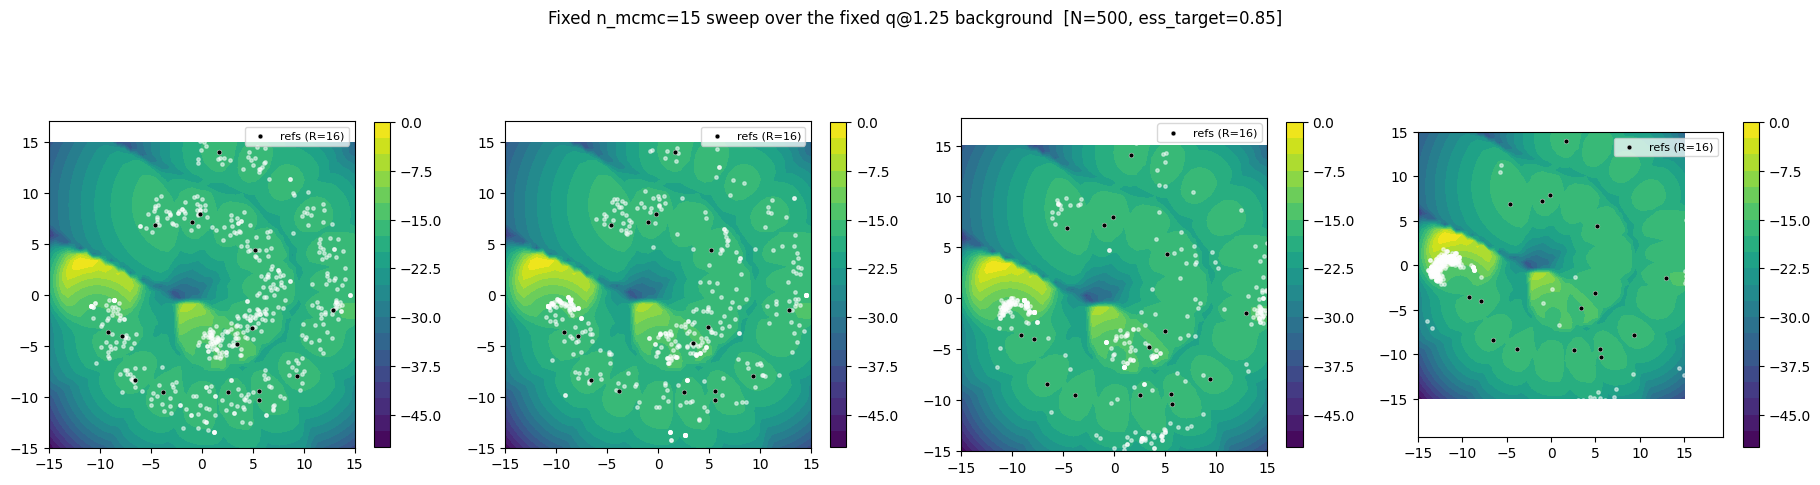

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from creativity_measure import plot_field, plot_samples

# Needs LAMBDA_S / reward / G / log_q_bg / rows from the SMC-only sweep cell above.
N_MCMC_FIX  = 15
LAMBDAS_FIX = [1.0, 1.5, 2.0, 3.0]

results_fix: dict[float, object] = {}
rows_fix: list[dict[str, float]] = []
fig, axes = plt.subplots(1, len(LAMBDAS_FIX), figsize=(4.6 * len(LAMBDAS_FIX), 4.7))
for ax, lam in zip(np.atleast_1d(axes), LAMBDAS_FIX):
    t = time.time()
    res = adaptive_tempering_smc_sample(reward, lam=lam, n_particles=N_SEL, kernel=PCNKernel(G, DDIM),
                     n_mcmc=N_MCMC_FIX, ess_target=ESS_TARGET, final_resample=True, seed=SEED)
    results_fix[lam] = res
    ef = float(reward(res.X).mean()); uniq = res.X.unique(dim=0).shape[0]; levels = len(res.betas)
    min_ess_n = min(res.ess_history) / N_SEL
    rows_fix.append(dict(lam=lam, ef_smc=ef, uniq_frac=uniq / N_SEL, min_ess_n=min_ess_n, levels=levels))
    print(f"lambda={lam:4.2f}  E_smc[f2]={ef:6.2f}  uniq/N={uniq/N_SEL:4.0%}  "
          f"min-ESS/N={min_ess_n:4.0%}  levels={levels:2d}  {time.time()-t:4.0f}s")
    plot_field(log_q_bg, XX, YY, ax=ax, refs=REFS,
               title=f"lambda = {lam}   (n_mcmc={N_MCMC_FIX})\nE[f2]={ef:.2f}   uniq/N={uniq/N_SEL:.0%}")
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"Fixed n_mcmc={N_MCMC_FIX} sweep over the fixed q@{LAM_BG} background  [N={N_SEL}, ess_target={ESS_TARGET}]",
    fontsize=12, y=1.05,
)
plt.tight_layout()
plt.show()

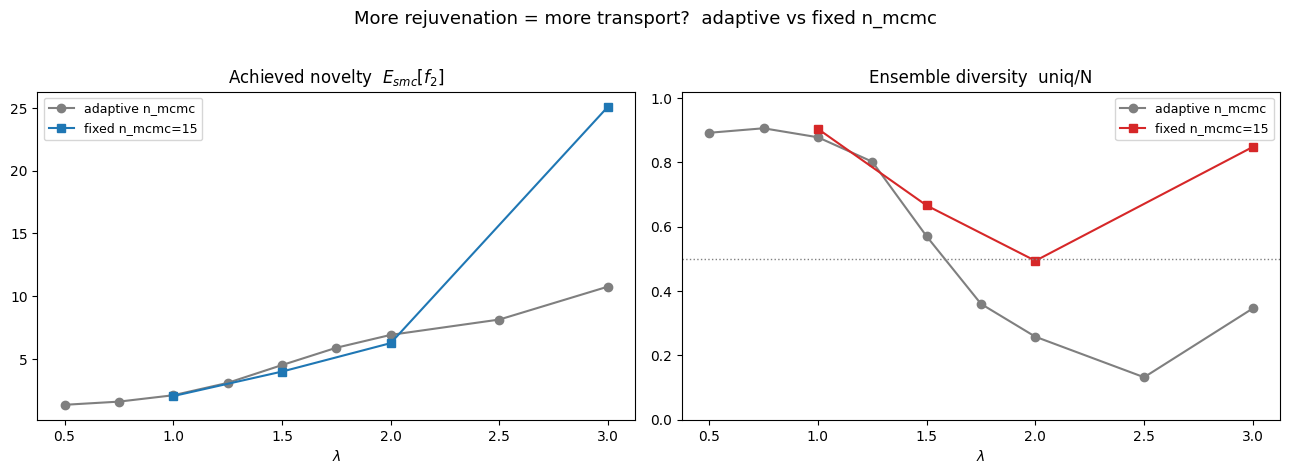

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

la = np.array([r["lam"] for r in rows]);      ea = np.array([r["ef_smc"] for r in rows]);      ua = np.array([r["uniq_frac"] for r in rows])
lf = np.array([r["lam"] for r in rows_fix]);  ef = np.array([r["ef_smc"] for r in rows_fix]);  uf = np.array([r["uniq_frac"] for r in rows_fix])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(la, ea, "o-", color="tab:gray", label="adaptive n_mcmc")
ax[0].plot(lf, ef, "s-", color="tab:blue", label=f"fixed n_mcmc={N_MCMC_FIX}")
ax[0].set_title("Achieved novelty  $E_{smc}[f_2]$"); ax[0].set_xlabel("$\\lambda$"); ax[0].legend(fontsize=9)
ax[1].plot(la, ua, "o-", color="tab:gray", label="adaptive n_mcmc")
ax[1].plot(lf, uf, "s-", color="tab:red",  label=f"fixed n_mcmc={N_MCMC_FIX}")
ax[1].axhline(0.5, color="gray", ls=":", lw=1); ax[1].set_ylim(0, 1.02)
ax[1].set_title("Ensemble diversity  uniq/N"); ax[1].set_xlabel("$\\lambda$"); ax[1].legend(fontsize=9)
fig.suptitle("More rejuvenation = more transport?  adaptive vs fixed n_mcmc", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Reading the fixed-`n_mcmc` repeat

- **The blue (fixed) curve sits above the gray (adaptive) one** for $E_{smc}[f_{2}]$ at matched $\lambda$ — and `uniq/N` holds up — the adaptive rule was under-transporting: the earlier $\lambda$ values were not too weak, it was an **effort** artifact (n_mcmc). For higher $\lambda$ values (and the $m\cdot\lambda_{s}$) the panels should now show a real progression and convergence toward certain spaces (hopefully "creative" ones).

- Should keep `uniq/N` above ~0.5 as the trust floor.

Let's try with stronger tilts, with the fixed-n_mcmc settings:

### Is $\lambda_{s}$ a good unit? — testing $m\cdot\lambda_{s}$

phase2 adopted a working point of $2\lambda_{0}$. The SMC-only analog is to treat $\lambda_{s}=1/\operatorname{std}_{p}(f_{2})$ as the **unit** and ask whether integer multiples land in the useful regime. The cell below runs SMC at $m\cdot\lambda_{s}$ for a chosen set of multipliers, plots the clouds over the same fixed $q_{\lambda=1.25}$ background, and prints the ratio $\lambda^{*}/\lambda_{s}$ for each auto-picked $\lambda^{*}$ so you can see whether a good $\lambda$ sits near an integer multiple.

lambda_s = 1.832   ->   m*lambda_s = [1.8321, 3.6642, 5.4964]   (n_mcmc=15)
m=1  lambda= 1.83  E_smc[f2]=  5.55  uniq/N= 49%  levels= 7   669s
m=2  lambda= 3.66  E_smc[f2]= 56.34  uniq/N= 70%  levels=25  2145s
m=3  lambda= 5.50  E_smc[f2]= 67.50  uniq/N= 10%  levels=35  2937s


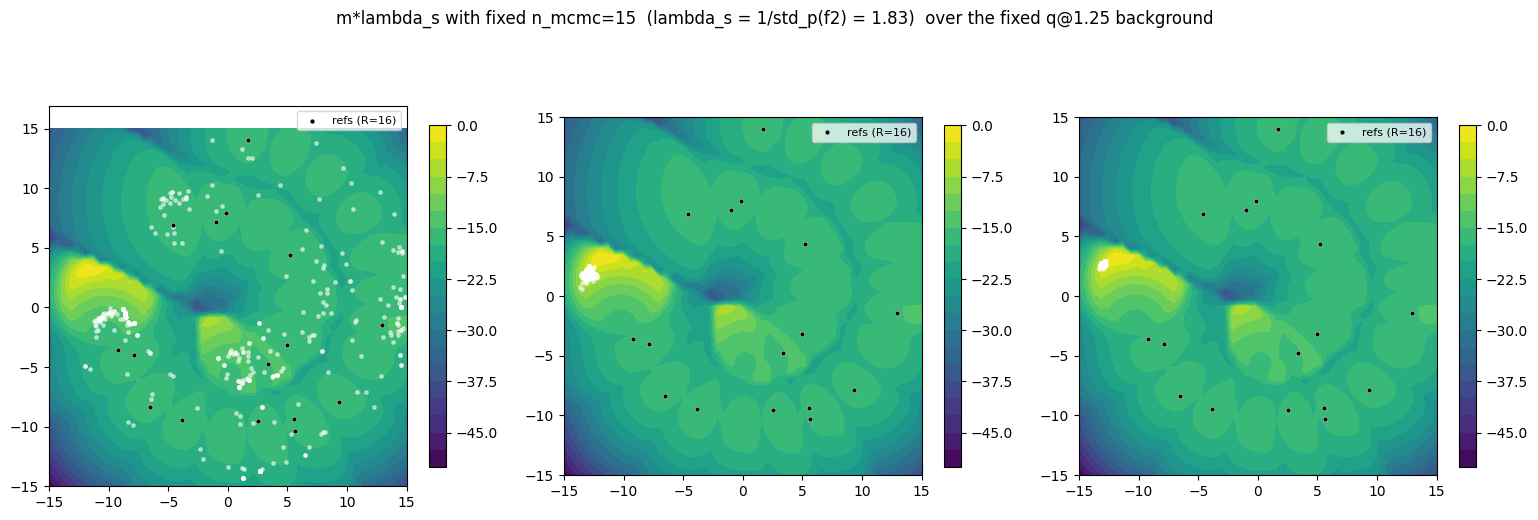

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from creativity_measure import plot_field, plot_samples

MULTS_FIX = [1, 2, 3]
LAMS_MULT = [round(m * LAMBDA_S, 4) for m in MULTS_FIX]
print(f"lambda_s = {LAMBDA_S:.3f}   ->   m*lambda_s = {LAMS_MULT}   (n_mcmc={N_MCMC_FIX})")

fig, axes = plt.subplots(1, len(MULTS_FIX), figsize=(5.2 * len(MULTS_FIX), 4.9))
for ax, m, lam in zip(np.atleast_1d(axes), MULTS_FIX, LAMS_MULT):
    t = time.time()
    res = adaptive_tempering_smc_sample(reward, lam=lam, n_particles=N_SEL, kernel=PCNKernel(G, DDIM),
                     n_mcmc=N_MCMC_FIX, ess_target=ESS_TARGET, final_resample=True, seed=SEED)
    ef = float(reward(res.X).mean()); uniq = res.X.unique(dim=0).shape[0]; levels = len(res.betas)
    print(f"m={m}  lambda={lam:5.2f}  E_smc[f2]={ef:6.2f}  uniq/N={uniq/N_SEL:4.0%}  "
          f"levels={levels:2d}  {time.time()-t:4.0f}s")
    plot_field(log_q_bg, XX, YY, ax=ax, refs=REFS,
               title=f"m={m}:  lambda = {lam:.2f} = {m}*lambda_s  (n_mcmc={N_MCMC_FIX})\n"
                     f"E[f2]={ef:.2f}   uniq/N={uniq/N_SEL:.0%}   levels={levels}")
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"m*lambda_s with fixed n_mcmc={N_MCMC_FIX}  (lambda_s = 1/std_p(f2) = {LAMBDA_S:.2f})  "
    f"over the fixed q@{LAM_BG} background",
    fontsize=12, y=1.05,
)
plt.tight_layout()
plt.show()